In [3]:
import torch
import matplotlib.pyplot as plt
from src.interp.kernel_regression import KernelRegression
import autoroot

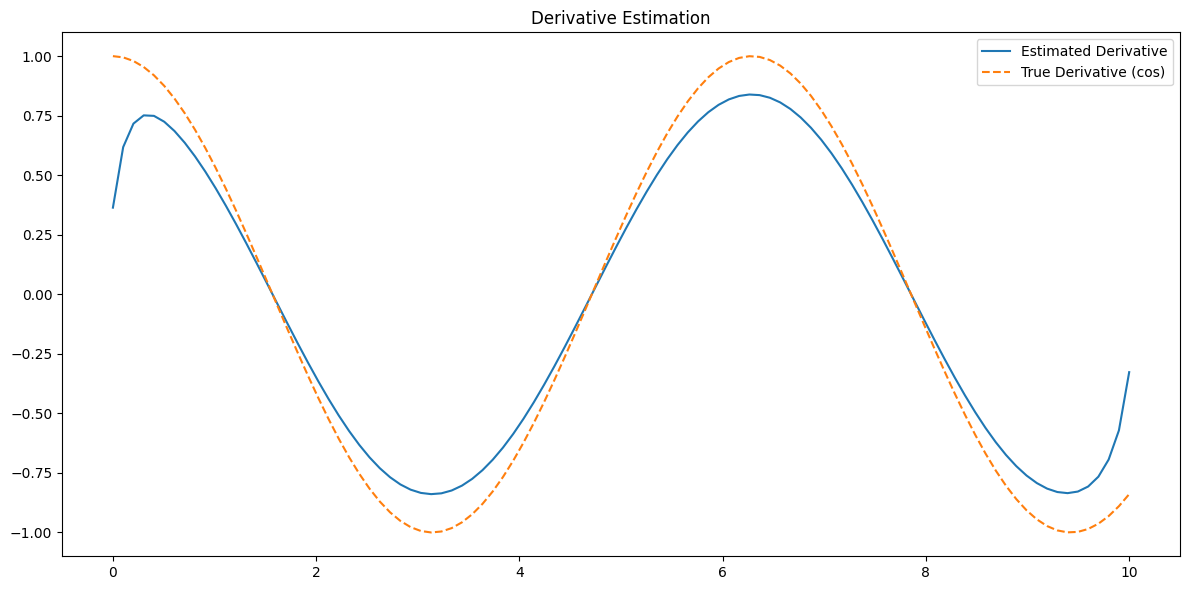

In [5]:
# Create synthetic data
L = 100
x = torch.linspace(0, 10, L).reshape(1, L)
y = torch.sin(x).reshape(1, 1, L, 1)

# Initialize and fit
regr = KernelRegression(bandwidth=0.1, temperature=0.1)  # More appropriate bandwidth
regr.fit(x, y, torch.zeros(1, 1, L))  # Assuming zeros for weights if not learned

# Get predictions and derivatives
t_eval = x  # Evaluate at observation points
preds = regr(t_eval)  # Forward pass (regression)
derivs = regr.forward(t_eval)  # Derivatives

# True values for comparison
true_fn = torch.sin(t_eval)
true_deriv = torch.cos(t_eval)

# Plotting
plt.figure(figsize=(12, 6))

# # Regression plot
# plt.subplot(1, 2, 1)
# plt.plot(t_eval.squeeze(), preds.squeeze(), label="Kernel Regression")
# plt.plot(t_eval.squeeze(), true_fn.squeeze(), "--", label="True Function")
# plt.scatter(x.squeeze(), y.squeeze(), c="r", s=10, label="Observations")
# plt.legend()
# plt.title("Function Approximation")

# Derivative plot
plt.subplot(1, 1, 1)
plt.plot(t_eval.squeeze(), derivs.squeeze(), label="Estimated Derivative")
plt.plot(t_eval.squeeze(), true_deriv.squeeze(), "--", label="True Derivative (cos)")
plt.legend()
plt.title("Derivative Estimation")

plt.tight_layout()
plt.show()
